# Равномерное распределение

Также мы можем определить ряд распределения для дискретного равномерного распределения с помощью Python.

In [1]:
import numpy as np
from scipy.stats import randint

Попробуем рассчитать вероятности для случайной величины, которая принимает значения от 1 включительно до 7 не включительно (собственно, это как раз пример с пирожными):

In [2]:
# Задаём возможные значения случайной величины
x = np.arange(1, 7)

# Задаём интервал, на котором будут распределяться наши вероятности
disc_uni_dist = randint(1, 7)

# Вычисляем вероятности выпадения каждого значения случайной величины
pmf = disc_uni_dist.pmf(x)

# Вывод
print(pmf)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


Так же можно найти кумулятивную вероятность для распредления, т.е для каждого $X_i$ вероятность, того что случайная величина примет значение $X_i$ или меньше:

In [3]:
# Рассчитаем кумулятивную вероятность
cdf = disc_uni_dist.cdf(x)

# Вывод
print(cdf)

[0.16666667 0.33333333 0.5        0.66666667 0.83333333 1.        ]


Вы участвуете в розыгрыше бесплатного места на новый курс по Data Science. Вы знаете, что участников 250.

Какова вероятность, что на курс попадёт кто-то из первых пятидесяти зарегистрировавшихся?

In [4]:
# Задаем возможные случайные величины
x = np.arange(1, 251)

# Задаем интервал, на котором распределяются наши вероятности
disc_uni_dist = randint(1, 251)

# Вычисляем вероятности выпадения для каждого значения случайно величины
cdf = disc_uni_dist.cdf(x)

# Ищем вероятность того, что на курс попадет кто-то из первых 50 зарегистрировавшихся
print(cdf[49])

0.2


В результате получаем 0.2 — это вероятность того, что выигрыш получит кто-то, чей порядковый номер — от 1 до 50. Разумеется, вероятность не зависит от самого номера, поэтому для номеров с 51 по 100 вероятность будет ровно такая же.

# Распределение Бернулли

С помощью специальной функции bernoulli.rvs() из библиотеки scipy мы можем смоделировать распределение Бернулли и, например, увидеть ожидаемое соотношение попаданий и промахов для решённой задачи, если будет сделано 500 выстрелов:

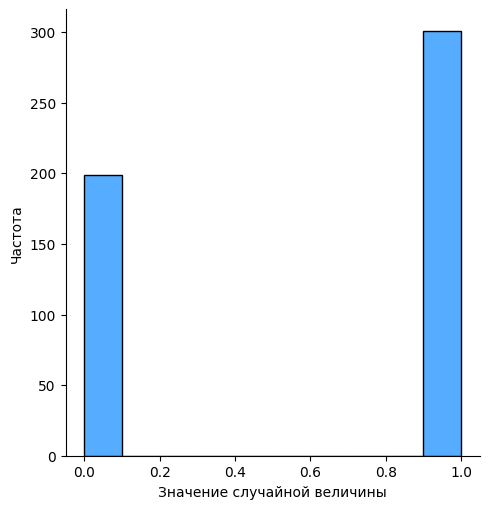

In [ ]:
# Импорт необходимых библиотек для работы со статистическим распределением и визуализацией данных
from scipy.stats import bernoulli  # Распределение Бернулли
import seaborn as sns  # Библиотека для построения графиков

# Генерируем 500 случайных значений из распределения Бернулли с параметром p=0.6
data = bernoulli.rvs(size=500, p=0.6)

# Строим гистограмму распределения Бернулли
ax = sns.displot(
    data=data,   # Исходные данные
    kde=False,   # Отключаем оценку плотности (она не имеет смысла для дискретного распределения)
    color='dodgerblue'  # Цвет столбцов гистограммы
)

# Настраиваем подписи осей
ax.set(xlabel='Значение случайной величины', ylabel='Частота')

Также можно вывести количество неудач и попаданий в нашей модели:

In [ ]:
# Количество неудач и попаданий в модели
unique, counts = np.unique(data, return_counts=True)

# Вывод количества каждого уникального значения
print(np.asarray((unique, counts)).T)

[[  0 199]
 [  1 301]]


Итак, мы получили результат, близкий к ожидаемому, но с некоторыми погрешностями, что, разумеется, является нормальным.

# Биноминальное распределение

Производитель гаджетов знает, что 20 % производимых им товаров — бракованные.

Если он производит десять изделий в день, какова вероятность того, что не более двух из них бракованные?

In [8]:
import scipy

# Задаем параметры для биномиального распределения
n = 10  # общее число изделий в день, производимых компанией
p = 0.8  # вероятность браковать одно изделие (20%)
k = [8, 9, 10]  # список чисел, которые мы ищем в биномиальном распределении

result = 0 # Инициируем переменную
for i in k:
    # Добавляем к общей вероятности вероятность события, когда бракуется не более двух товаров в день
    result += scipy.stats.binom.pmf(i, n, p) 

# Выводим результат
print(round(result, 3))

0.678


Получаем, что с вероятностью 0.678 будет производиться не более двух бракованных изделий в день.

Как и для распределения Бернулли, для биномиального распределения можно смоделировать какое-то количество попыток и получить результат. Например, можно смоделировать биноминальное распределение с параметром p = 0.5 и количеством испытаний, равным 10, и реализовать 1000 попыток:

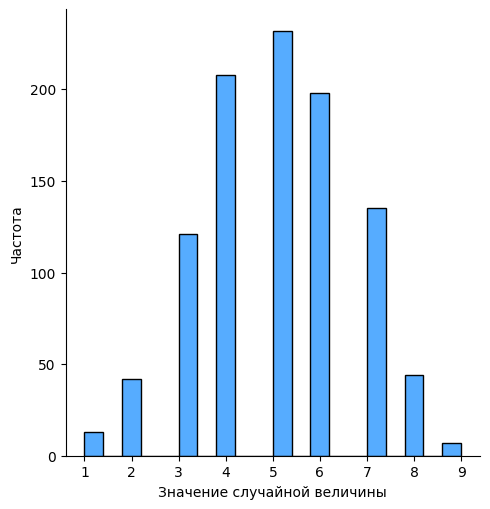

In [ ]:
# Импортируем необходимые библиотеки
from numpy import random  # Для генерации случайных чисел
import seaborn as sns  # Для визуализации данных

# Генерируем 1000 случайных чисел из биномиального распределения
# n=10 - количество испытаний (например, подбрасываний монеты)
# p=0.5 - вероятность успеха в каждом испытании (например, выпадение орла)
# size=1000 - количество случайных значений в выборке
data = random.binomial(n=10, p=0.5, size=1000)

# Строим гистограмму биномиального распределения
# kde=False - отключаем ядерную оценку плотности, так как данные дискретные
# color='dodgerblue' - задаём синий цвет гистограммы
ax = sns.displot(data, kde=False, color='dodgerblue')

# Устанавливаем подписи осей
ax.set(xlabel='Значение случайной величины', ylabel='Частота')

Можно видеть, что чаще всего можно наблюдать пять успешных исходов.

# Распределение Пуассона

Колл-центр получает в среднем 4.5 звонка за каждые пять минут. Каждый оператор может обработать один из этих вызовов в течение пяти минут. Если вызов получен, но оператор не может его принять, то вызывающий абонент будет переведён в режим ожидания ответа.

Если вызовы следуют распределению Пуассона, какое минимальное количество операторов необходимо колл-центру, чтобы вероятность попадания вызова на удержание была не более 0.1?

In [ ]:
# Импортируем библиотеку scipy
import scipy

# Вычисляем вероятность (PMF) для распределения Пуассона
# pmf(k, λ) - вероятность получить k событий при среднем количестве λ
# В данном случае: k = 5, λ = 4.5
result = scipy.stats.distributions.poisson.pmf(5, 4.5)

# Выводим результат, округленный до 3 знаков после запятой
print(round(result, 3))

0.171


Также можно смоделировать распределение Пуассона. Например, будем рассматривать 1000 реализаций случайной величины, у которой $\lambda$ = 3:

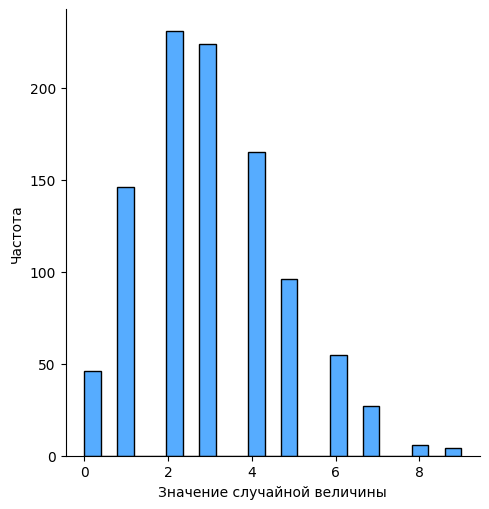

In [ ]:
# Импортируем необходимые библиотеки
from numpy import random  # Генерация случайных чисел
import seaborn as sns  # Библиотека для визуализации данных

# Генерируем 1000 случайных чисел из распределения Пуассона
# lam=3 - среднее число событий за фиксированный интервал (параметр λ)
# size=1000 - количество генерируемых значений
data = random.poisson(lam=3, size=1000)

# Строим гистограмму распределения Пуассона
# kde=False - отключаем ядерную оценку плотности, так как данные дискретные
# color='dodgerblue' - задаём синий цвет гистограммы
ax = sns.displot(data, kde=False, color='dodgerblue')

# Устанавливаем подписи осей
ax.set(xlabel='Значение случайной величины', ylabel='Частота')

# Практика:

Вы стреляете по мишени. Вероятность набрать максимальное количество очков составляет 7 %. В этом случае вы выиграете плюшевого медведя стоимостью 5000 рублей. Если наберёте меньше максимума, то не выиграете ничего.

Сколько должен стоить билет, чтобы обеспечить игру, в которой выигрыш равен вашим ожидаемым затратам и ожидаемым затратам продавца?


In [34]:
# Используем формулу распределения Бернулли

сost = 5000 # Стоимость выйрыша
p = 0.07 # Вероятность выйгрыша

# Математическое ожидание
EX = 1 * p + 0 * (1 - p)

# Рассчитываем стоимость билета
ticket_price = EX * сost + (1 - p) * 0
print(f'Стоимость билета должна быть: {round(ticket_price)} руб')

Стоимость билета должна быть: 350 руб


Вы купили 85 лотерейных билетов. Для каждого из них вероятность выигрыша составляет 0.001.

Найдите математическое ожидание для количества выигрышных билетов.

In [54]:
# Используем биноминальное распределение (т.к. у нас только два исхода выйграл и проиграл)
n = 85 # Количество билетов
p = 0.001 # Вероятность успеха

EX = n * p
print(f'Математическое ожидание составит: {EX}')

Математическое ожидание составит: 0.085


Иван Петрович 20 лет живёт в доме, в котором 30 лифтов и одна кнопка для их вызова. За это время он провёл много измерений и предполагает, что если нажать на кнопку, то количество лифтов, пришедших за минуту, подчиняется распределению Пуассона, с $\lambda=2$. Это значит, что:

In [ ]:
# Распределение Пуассона
lmd = 2 # лямбда по задаче у нас 2
min = 1 # за одну минуту
result = scipy.stats.poisson.rvs(min, lmd)
print(f'За {min} минуту в среднем приедет {result} лифта') # Приедет 2 лифта

За 1 минуту в среднем приедет 2 лифта


Сеть ресторанов быстрого питания проводит акцию, в рамках которой в одной из четырёх коробок картофеля фри лежит купон на бесплатную коробку картофеля фри. Предположим, что где-то продаётся 100 таких коробок в день. Пусть  равно количеству выигранных купонов за день.

Найдите среднее значение и стандартное отклонение для . Если результат дробное число, округлите ответ до одного знака после точки-разделителя.

In [68]:
# Биноминальное распределение
n = 100 # Количество упаковок в день
p = 1/4 # Вероятность выйгрыша (в одной из четырех) # 
# X ~ bin = (n = 100, p = 0.25)

# Среднее значение
EX = n * p
print(f'Среднее значение: {EX}')

# Стандартное отклонение
SIGMA_X = np.sqrt(n * p * (1 - p))
print(f'Стандартное отклонение: {round(SIGMA_X, 1)}')

Среднее значение: 25.0
Стандартное отклонение: 4.3


Пассажиры прибывают на вокзал со средней скоростью $\lambda = 4$ человека в минуту.

Если количество пассажиров, приезжающих на вокзал, подчиняется распределению Пуассона, какова приблизительная вероятность того, что 16 пассажиров приедут на вокзал в конкретный четырёхминутный период? Округлите ответ до трёх знаков после точки-разделителя.

In [71]:
# Распределение Пуассона
min = 4 # Четырехминутный период
lmd = 4 * 4 # Здесь 4 человека в минуту, здачит умножаем 4 минуты на 4 человека
k = 16 # Количество пассажиров

result = scipy.stats.poisson.pmf(k, lmd)
# Вывод
print(f'Вероятность, что {k} пассажиров приедут на вокзал в четырехминутный период: {round(result, 3)}')

Вероятность, что 16 пассажиров приедут на вокзал в четырехминутный период: 0.099


# Равномерное распределение

Мы можем с помощью Python смоделировать случайную величину c таким распределением и визуализировать плотность её распределения. К примеру, сформируем выборку объёмом 10000 для распределения с параметрами a = 10 и b = 40.

Примечание: В коде задаётся начало интервала (loc=10) и его длина (scale=30).

Сам интервал [a,b] определяется так: 𝑏 = 𝑎 + scale = 10 + 30 = 40

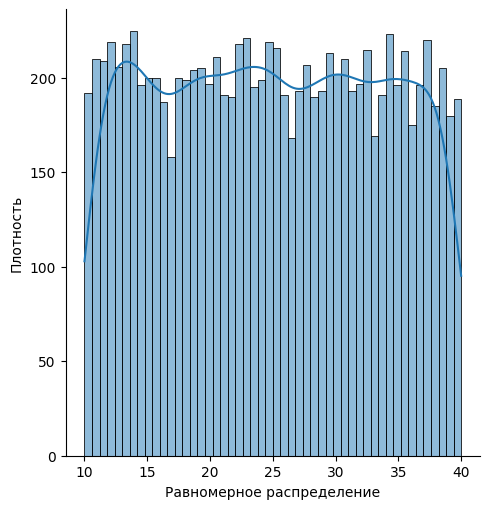

In [2]:
# Импортируем необходимые библиотеки
from scipy.stats import uniform  # Генерация случайных чисел из равномерного распределения
import seaborn as sns  # Визуализация данных

# Генерируем 1000 случайных значений из равномерного распределения
# loc=10 - начальное значение (a)
# scale=30 - длина интервала (b - a)
data = uniform.rvs(size=10000, loc=10, scale=30)

# Строим гистограмму распределения с KDE (ядерной оценкой плотности)
ax = sns.displot(data, kde=True, bins=50)

# Устанавливаем подписи осей
ax.set(xlabel='Равномерное распределение', ylabel='Плотность')

По графику плотности распределения видно, что в рамках интересующего нас интервала все значения сгенерированы примерно с одной частотой. Разумеется, есть некоторые колебания, но с реальными данными у вас всегда будет получаться именно такая картина, отличная от идеального теоретического предположения.

# Нормальное распределение

Cмоделируем нормальное распределение с математическим ожиданием, равным 5, и стандартным отклонением, равным 4, и посмотрим, какой вид оно примет.

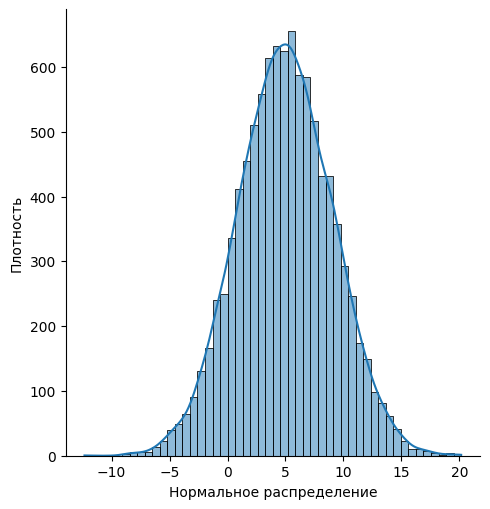

In [4]:
# Импортируем необходимые библиотеки
from scipy.stats import norm  # Генерация случайных чисел из нормального распределения
import seaborn as sns  # Визуализация данных

# Генерируем 10 000 случайных значений из нормального (Гауссовского) распределения
# loc=5 - математическое ожидание (среднее значение)
# scale=5 - стандартное отклонение (мера разброса данных)
data = norm.rvs(size=10000, loc=5, scale=4)

# Строим гистограмму распределения с KDE (ядерной оценкой плотности)
ax = sns.displot(data, kde=True, bins=50)

# Устанавливаем подписи осей
ax.set(xlabel='Нормальное распределение', ylabel='Плотность')

# Cтандартизация

Такая стандартизация используется также в машинном обучении, чтобы привести признаки к одной шкале измерения — это сильно повышает качество моделей.

In [7]:
# Импортируем функцию asarray из библиотеки numpy для преобразования данных в массив numpy
from numpy import asarray
# Импортируем класс StandardScaler из sklearn.preprocessing для стандартизации данных
from sklearn.preprocessing import StandardScaler

# Создаем исходные данные в виде 2D массива, где каждая строка представляет собой наблюдение,
# а каждый столбец — отдельный признак (фичу)
data = asarray([[93, 44],
                [4, 2],
                [36, 1],
                [14, 29],
                [78, 21]])

# Выводим исходные данные на экран
print(data)

# Создаем объект класса StandardScaler для стандартизации данных
scaler = StandardScaler()

# Применяем метод fit_transform:
# - fit: вычисляет среднее и стандартное отклонение для каждого столбца (признака)
# - transform: стандартизирует данные, вычитая среднее и деля на стандартное отклонение
data_scaled = scaler.fit_transform(data)

# Выводим стандартизированные данные, где каждый столбец имеет среднее значение 0 и стандартное отклонение 1
print(data_scaled)

[[93 44]
 [ 4  2]
 [36  1]
 [14 29]
 [78 21]]
[[ 1.37243726  1.50201177]
 [-1.17229016 -1.06239857]
 [-0.25733199 -1.12345596]
 [-0.88636573  0.58615094]
 [ 0.94355062  0.09769182]]


# Примеры:

Дана случайная величина, распределённая по следующему закону:

Распределена нормально!

$X = N(4, 5^2)$

1. Чему равно математическое ожидание X?

2. Чему равно стандартное отклонение X?

In [18]:
import numpy as np

# Если данные распределены нормально, значит используем следующие формулы:

a = 4 # Математическое ожидание
b = 5**2 # Дисперсия

X = a
print(f'Математическое ожидание: {EX}')

SIGMA_X = np.sqrt(b)
print(f'Стандартное отклонение: {round(SIGMA_X)}')

# Чтобы стандартизировать, нужно сначала вычесть 4 и поделить на 5
z = EX/SIGMA_X
print(z)

Математическое ожидание: 4
Стандартное отклонение: 5
0.8


# Экспоненциальное распределение

С помощью Python мы можем смоделировать экспоненциальное распределение так:

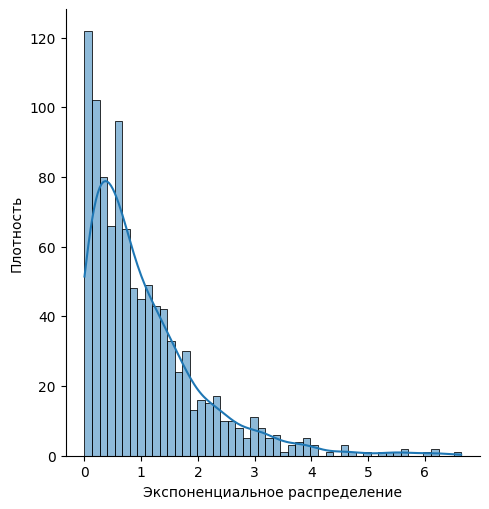

In [20]:
# Импортируем функцию rvs из модуля scipy.stats для генерации случайных чисел из экспоненциального распределения
from scipy.stats import expon

# Импортируем библиотеку seaborn для визуализации данных
import seaborn as sns

# Генерируем 1000 случайных значений из экспоненциального распределения
# scale=1 - параметр масштаба (среднее значение распределения, для экспоненциального распределения это также и математическое ожидание)
# loc=0 - смещение распределения (в данном случае оно равно 0)
# size=1000 - количество случайных значений, которые мы генерируем
data = expon.rvs(scale=1, loc=0, size=1000)

# Строим гистограмму с ядровой оценкой плотности (KDE)
# bins=50 - количество корзин для гистограммы
# kde=True - включаем отображение ядровой оценки плотности поверх гистограммы
ax = sns.displot(data, kde=True, bins=50)

# Устанавливаем подписи для осей
ax.set(xlabel='Экспоненциальное распределение', ylabel='Плотность')

Математическое ожидание для этого распределения вычисляется по следующей формуле:

$$EX = 1/\lambda$$

Стандартное отклонение можно найти ровно так же:

$$\sigma_x = 1/\lambda$$

Вероятность того, что значение случайной величины будет не больше x, равна:

$$1 - e^-\lambda_x$$

# Пример:

Иван Петрович 20 лет живёт в доме, в котором 30 лифтов и одна кнопка для их вызова. За это время он выявил, что если нажать на кнопку, то количество лифтов, пришедших за минуту, подчиняется экспоненциальному распределению с $\lambda=2$. Это значит, что...

In [ ]:
# Параметр распределения
lambda_value = 2

# Время (или количество лифтов) для расчета вероятности
x = 1

# Вычисление вероятности с использованием экспоненциального распределения
P = 1 - np.exp(-lambda_value * x)

# Вывод результата
print(P)

0.8646647167633873


Экспоненциальное распределение и его интерпретация:

1. Параметр λ=2: Это интенсивность распределения, которая определяет среднее количество событий (в данном случае, лифтов), происходящих в единицу времени.

- λ=2 означает, что в среднем за одну минуту приходит 2 лифта.

2. Среднее время до следующего события: Экспоненциальное распределение характеризуется тем, что среднее время между событиями (в данном случае — временем, которое Ивану Петровичу нужно ждать до следующего лифта) равно 1/𝜆.

- Так как λ=2, то среднее время ожидания (интервал между приходами лифтов) составляет:
1/𝜆 = 1/2 = 0.5 минуты

То есть, в среднем лифт приходит каждые полминуты.

3. Результат вероятности P: Вероятность P=0.8647 означает, что с вероятностью 86.47% за одну минуту прибудет менее одного лифта. Это подтверждает, что если ждать 1 минуту, вероятность того, что за это время прибудет хотя бы один лифт, довольно высокая, так как среднее время ожидания составляет 0.5 минуты.

В среднем новый холодильник служит 10 лет. Предположим, что продолжительность времени службы распределена экспоненциально.

Примечание: Как вычисляется параметр $\lambda$?
Экспоненциальное распределение имеет параметр $\lambda$, который связан с средним временем между событиями. Если известно, что средняя продолжительность жизни холодильника — 10 лет, то λ будет равен:

$\lambda = \frac{1}{среднее время службы} = \frac{1}{10}$
​
1. Какова вероятность того, что холодильник прослужит более 7 лет?

2. Какова вероятность того, что устройство прослужит от 9 до 11 лет?

In [28]:
lambda_value = 1/10 # 1 делим на 10 лет службы холодильника
x = 7 # срок службы

# Вычисление вероятности того, что холодильник прослужит более 7 лет
P_1 = np.exp(-lambda_value * x)
print(f'Вероятность того, что холодильник прослужит более 7 лет: {P_1:.3f}')

# Рассчитываем вероятности для 9 и 11 лет
P_11 = 1 - np.exp(-lambda_value * 11) # Вероятность того, что устройство прослужит менее 11 лет
P_9 = 1 - np.exp(-lambda_value * 9) # Вероятность того, что устройство прослужит менее 9 лет

# Вычисление вероятности, что устройство прослужит от 9 до 11 лет
P_2 = P_11 - P_9
print(f'Вероятность того, что устройство прослужит от 9 до 11 лет: {P_2:.3f}')

Вероятность того, что холодильник прослужит более 7 лет: 0.497
Вероятность того, что устройство прослужит от 9 до 11 лет: 0.074


В вашем офисе стоят два автомата, с кофе и с чаем. Вероятность того, что к концу дня ваши коллеги выпьют весь кофе, равна 0.22. Для чая соответствующая вероятность равна 0.3.

Найдите вероятность того, что хотя бы в одном из автоматов закончится напиток.

In [34]:
P_coffee_end = 0.2 # Закончится кофе
P_tea_end = 0.3 # Закончится чай
P_tea_coffee_end = P_coffee_end * P_tea_end # Вероятность, что закончится и кофе и чай

# Вычисляем вероятность того, что хотя бы в одном из автоматов закончится напиток
P_full = (P_coffee_end) + (P_tea_end) - P_tea_coffee_end
print(f'вероятность того, что хотя бы в одном из автоматов закончится напиток: {P_full}')

вероятность того, что хотя бы в одном из автоматов закончится напиток: 0.44


Вы находитесь на благотворительном мероприятии и приобрели один билет для участия в розыгрыше.

Вам сообщают, что на мероприятии будет 200 человек (включая вас), и примерно 3/4 участников мероприятия приобрели билеты на розыгрыш. Из этих людей равное количество купило один, два и три билета соответственно.

Если основываться на этих оценках и предполагать, что победитель будет только один, какова вероятность того, что вы выиграете? Ответ округлите до трёх знаков после точки-разделителя.

In [55]:
# Задаем параметры
total_players = 200  # Общее количество участников
p_buy_ticket = 3/4  # Доля участников, купивших билеты
players_buy_tickets = round(p_buy_ticket * total_players)  # Количество участников, купивших билеты 150

# Распределяем участников по количеству билетов: 1, 2, 3
one_ticket = players_buy_tickets / 3 # 50 человек
two_tickets = players_buy_tickets / 3 # 50 человек
three_tickets = players_buy_tickets - (one_ticket + two_tickets) # Остальные получат по 3 билета # 50

# Общее количество билетов
total_tickets = one_ticket * 1 + two_tickets * 2 + three_tickets * 3

# моя вероятность выйграть
my_tickets = 1 # Я приобрет 1 билет
p_to_win = my_tickets / total_tickets # Вероятность того, что именно ваш билет выиграет

# Выводим результат
print(f'Вероятность того, что вы выиграете: {round(p_to_win, 3)}')

Вероятность того, что вы выиграете: 0.003


Согласно прогнозу погоды на завтра, с вероятностью 50 % будет дождь в Пекине, с вероятностью 30 % — в Рио-де-Жанейро и с вероятностью 20 % — в Найроби.

Какова вероятность того, что завтра ни в одном из трёх указанных городов не будет дождя?

Поскольку эти три города находятся далеко друг от друга, предположим, что случаи дождя в этих городах независимы.

In [65]:
# Вероятность того, что будет дождь
P_rain_Nijing = 0.5
P_rain_Rio = 0.3
P_rain_Nairobi = 0.2

# Вероятности того, что дождя не будет в каждом городе
P_no_rain_Nijing = 1.0 - P_rain_Nijing
P_no_rain_Rio = 1.0 - P_rain_Rio
P_no_rain_Nairobi = 1.0 - P_rain_Nairobi

# Вероятность, того что дождя ни в одном городе не будет
P_full_not_raining = P_no_rain_Nijing * P_no_rain_Rio * P_no_rain_Nairobi
print(f'Вероятность, что дождя ни в одном городе не будет: {P_full_not_raining:.3f}')

Вероятность, что дождя ни в одном городе не будет: 0.280
